# 3. Strategy: Costs, Markups, and Profit

## This part of the work is the **pricing analyst** or **applied economist** role: using a demand model to reason about price, cost, and profitability. This kind of analysis could be used to think about investing in this market, or how to adjust a product line to be more competitive.

Now use the demand estimate to infer market fundamentals.

The price coefficient is constant across brands and years, $\hat{\beta}_{price}$.

For each brand-year, compute the slope of demand with respect to price as:

$$
\hat{s}'_{bt}(p_{bt}) = \hat{\beta}_{price} s_{bt}(1 - s_{bt}).
$$

Then estimate unit cost, or marginal cost, using the firm's first-order pricing condition:

$$
\hat{c}_{bt} = p_{bt} + \frac{s_{bt}}{\hat{s}'_{bt}(p_{bt})}.
$$

Because $\hat{\beta}_{price}$ should be negative, $\hat{s}'_{bt}(p_{bt})$ should also be negative. If your price coefficient is positive, stop and debug your model before interpreting costs.

First, make the model again using code from the `data_scientist.ipynb` and verify that the price coefficient is negative.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

df = pd.read_csv("air_fryers_clean_brand_year.csv")

feature_cols = ["compact_share", "dual_basket_share",
    "oven_style_share",
    "rotisserie_share",
    "window_share"
]

brand_dummies = pd.get_dummies(
    df["brand"], prefix="brand",
    drop_first=True,
    dtype=int
)

year_dummies = pd.get_dummies(
    df["year"].astype(str),
    prefix="year",
    drop_first=True,
    dtype=int
)

X = pd.concat(
    [
        df[["avg_price", "avg_rating"] + feature_cols],
        brand_dummies,
        year_dummies
    ],
    axis=1
)

y = df["log_brand_share"]

model = LinearRegression()
model.fit(X, y)

predicted_log_share = model.predict(X)

coef_table = pd.DataFrame({
    "variable": X.columns,
    "coefficient": model.coef_
})

# display(coef_table)

In [3]:
price_coef = coef_table.loc[
    coef_table["variable"] == "avg_price",
    "coefficient"
].iloc[0]

print("price coefficient:", round(price_coef, 4))

price coefficient: -0.0377


Compute:

- `demand_slope`: $\hat{s}'_{bt}(p_{bt})$
- `unit_cost`: $\hat{c}_{bt}$
- `markup`: $m_{bt} = p_{bt} - \hat{c}_{bt}$
- `average_profit`: $s_{bt} \times m_{bt}$

Here `average_profit` is a share-weighted profit index, not total dollars of profit. It is useful for comparing brand-years inside this cleaned market.

In [4]:
pricing_df = df.copy()

pricing_df["demand_slope"] = (
    price_coef
    * pricing_df["brand_share"]
    * (1 - pricing_df["brand_share"])
)

pricing_df["unit_cost"] = (
    pricing_df["avg_price"]
    + pricing_df["brand_share"] / pricing_df["demand_slope"]
)   

pricing_df["markup"] = (
    pricing_df["avg_price"]
    - pricing_df["unit_cost"]
)

pricing_df["average_profit"] = (
    pricing_df["brand_share"]
    * pricing_df["markup"]
)

display(pricing_df.head())

,category,year,brand,purchase_count,product_count,avg_price,avg_rating,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share,market_purchases,brand_share,log_brand_share,demand_slope,unit_cost,markup,average_profit
0,air_fryers,2019,chefman,1146,10,72.963695,4.434119,1.000000,0.0,0.780977,0.243455,0.184119,15076,0.076015,-2.576826,-0.002646,44.231656,28.732039,2.184062
1,air_fryers,2019,cosori,11,2,159.990000,4.581818,1.000000,0.0,0.090909,0.090909,0.000000,15076,0.000730,-7.222964,-0.000027,133.422638,26.567362,0.019385
2,air_fryers,2019,cuisinart,1616,22,229.465274,4.481312,0.993812,0.0,0.889851,0.000000,0.000000,15076,0.107190,-2.233150,-0.003605,199.729962,29.735313,3.187335
3,air_fryers,2019,dash,3011,19,55.176333,4.390767,1.000000,0.0,0.973431,0.000000,0.000000,15076,0.199721,-1.610832,-0.006021,22.002913,33.173420,6.625442
4,air_fryers,2019,gowise usa,4405,45,83.575551,4.552259,0.999773,0.0,0.129398,0.128490,0.000000,15076,0.292186,-1.230364,-0.007790,46.068541,37.507010,10.959033


### What are the average unit costs and markups for each brand over the years?

In [5]:
# Average unit costs and markups by brand over the years
brand_cost_markup = pricing_df.groupby("brand")[
    ["unit_cost", "markup", "average_profit"]
].mean().sort_values("average_profit", ascending=False)

display(brand_cost_markup)

,unit_cost,markup,average_profit
brand,,,
ninja,112.488470,32.854071,6.306093
instant_pot,71.903119,32.558234,6.010256
gowise usa,56.301040,31.153741,4.605764
dash,27.936578,29.542349,2.994372
chefman,61.569466,29.368946,2.820968
ultrean,48.785765,29.328841,2.780864
cuisinart,194.896119,29.050974,2.502997
cosori,86.283321,27.984628,1.436651
nuwave,109.053549,27.970835,1.422858


On average, **Ninja** and **Instant Pot** have the highest markups and average profit. **Cuisinart** and **Oster** have the highest estimated unit costs, likely because their average prices are much higher.

### Are any inferred unit costs negative? If so, what might that mean?

In [6]:
# Check for negative inferred unit costs
negative_costs = pricing_df[pricing_df["unit_cost"] < 0]

display(negative_costs[["brand", "year", "avg_price", "brand_share", "unit_cost"]])
print("Number of negative unit costs:", len(negative_costs))

,brand,year,avg_price,brand_share,unit_cost


Number of negative unit costs: 0


There are **no negative inferred unit costs** in this model. If negative costs appeared, it would suggest a problem with the demand estimate, pricing assumptions, or data quality.

### Which brands have the highest average unit costs? How do average unit cost and average ratings compare? Make scatter plots of price vs. unit cost and average rating vs. unit cost. Do more expensive products have higher consumer satisfaction?

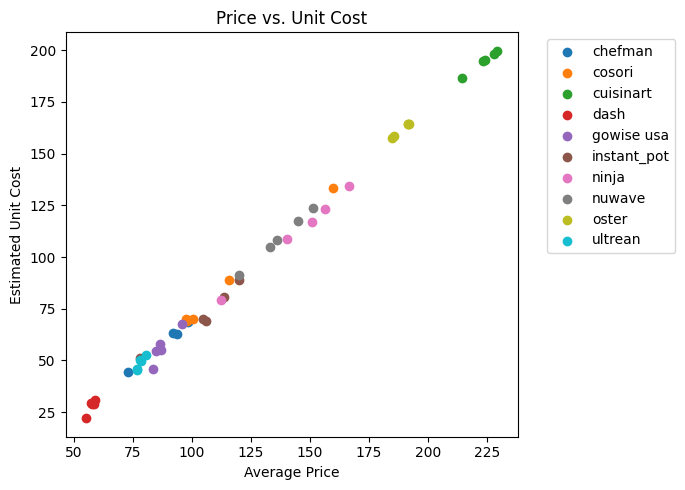

In [7]:
# price vs. unit cost
plt.figure(figsize=(7, 5))

for brand, group in pricing_df.groupby("brand"):
    plt.scatter(group["avg_price"], group["unit_cost"], label=brand)

plt.title("Price vs. Unit Cost")
plt.xlabel("Average Price")
plt.ylabel("Estimated Unit Cost")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

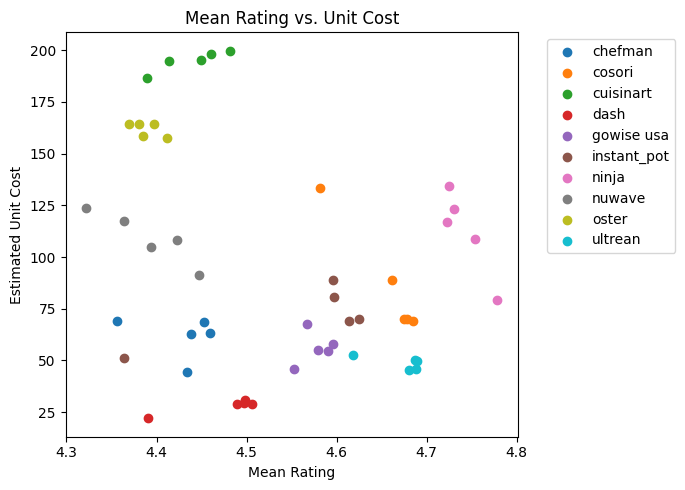

In [8]:
# Scatter plot: average rating vs. unit cost
plt.figure(figsize=(7, 5))

for brand, group in pricing_df.groupby("brand"):
    plt.scatter(group["avg_rating"], group["unit_cost"], label=brand)

plt.title("Mean Rating vs. Unit Cost")
plt.xlabel("Mean Rating")
plt.ylabel("Estimated Unit Cost")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

Brands with higher prices generally have higher estimated unit costs. However, higher unit cost does not clearly correspond to higher average ratings. More expensive products do not always appear to have higher consumer satisfaction.

### Make kernel density plots of unit costs, markups, and average profit, in general and hued by brand.

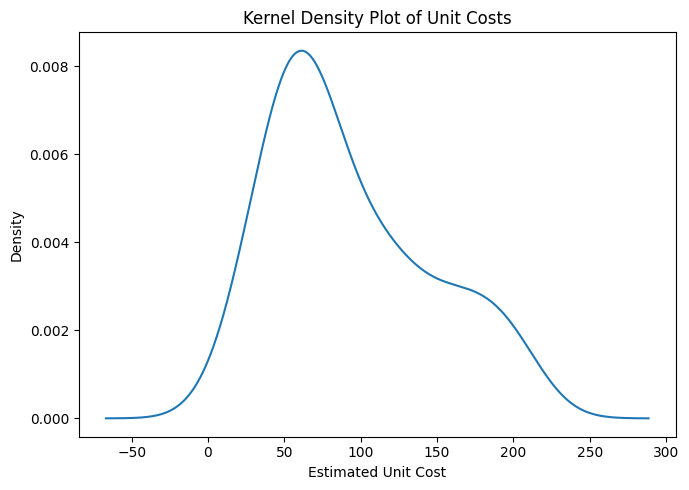

In [9]:
# KDE plot of unit costs
plt.figure(figsize=(7, 5))

pricing_df["unit_cost"].plot(kind="kde")

plt.title("Kernel Density Plot of Unit Costs")
plt.xlabel("Estimated Unit Cost")

plt.tight_layout()
plt.show()

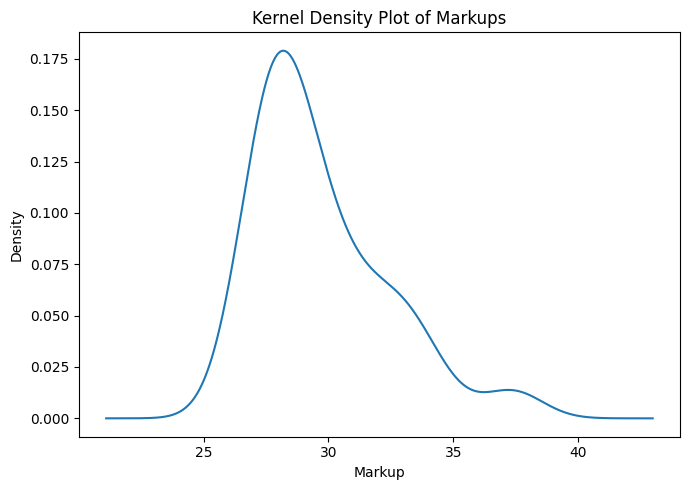

In [10]:
# markups
plt.figure(figsize=(7, 5))

pricing_df["markup"].plot(kind="kde")

plt.title("Kernel Density Plot of Markups")
plt.xlabel("Markup")

plt.tight_layout()
plt.show()

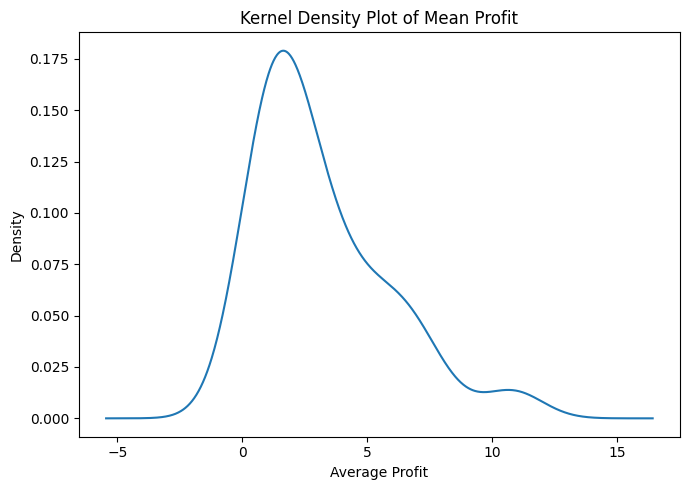

In [11]:
# mean profit
plt.figure(figsize=(7, 5))

pricing_df["average_profit"].plot(kind="kde")

plt.title("Kernel Density Plot of Mean Profit")
plt.xlabel("Average Profit")

plt.tight_layout()
plt.show()

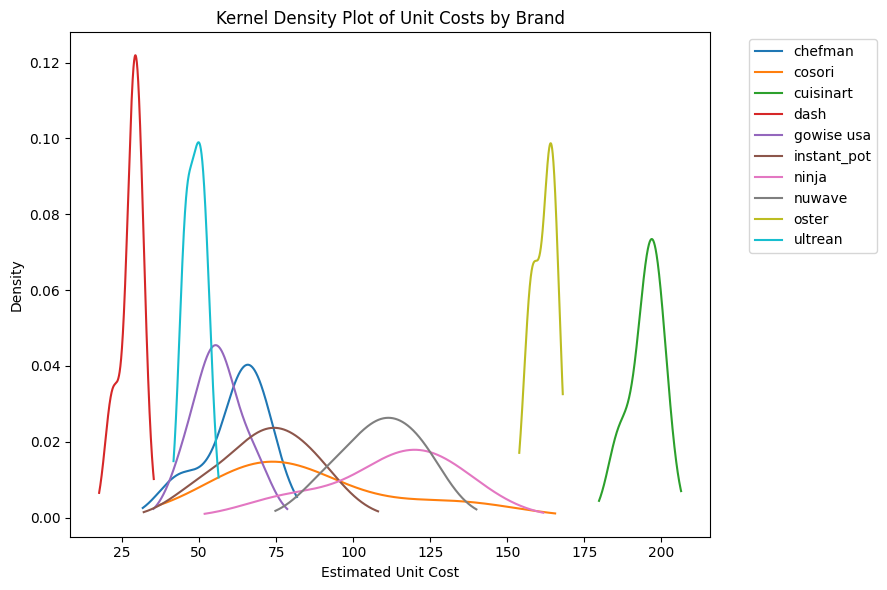

In [12]:
# unit costs by brand
plt.figure(figsize=(9, 6))

for brand, group in pricing_df.groupby("brand"):
    group["unit_cost"].plot(kind="kde", label=brand)

plt.title("Kernel Density Plot of Unit Costs by Brand")
plt.xlabel("Estimated Unit Cost")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

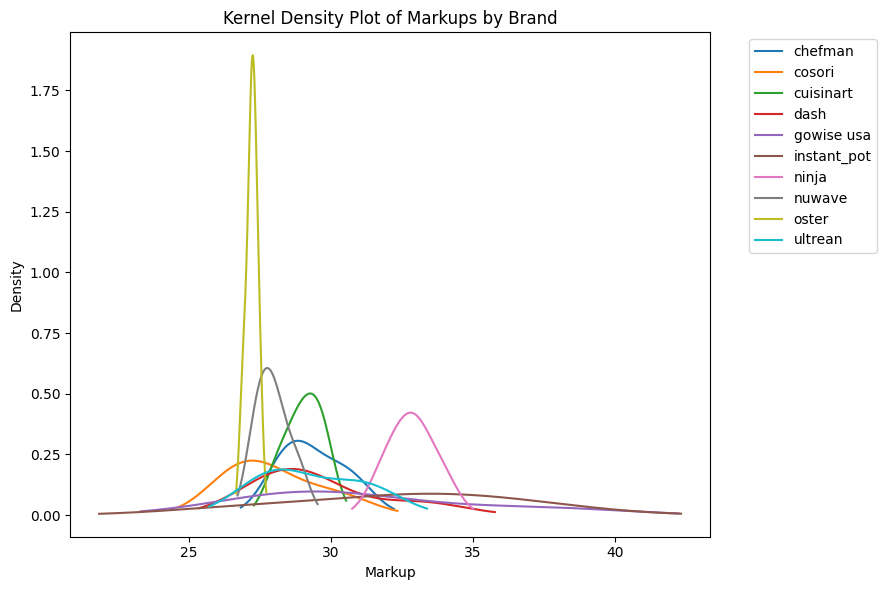

In [16]:
#  markups by brand
plt.figure(figsize=(9, 6))

for brand, group in pricing_df.groupby("brand"):
    group["markup"].plot(kind="kde", label=brand)

plt.title("Kernel Density Plot of Markups by Brand")
plt.xlabel("Markup")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

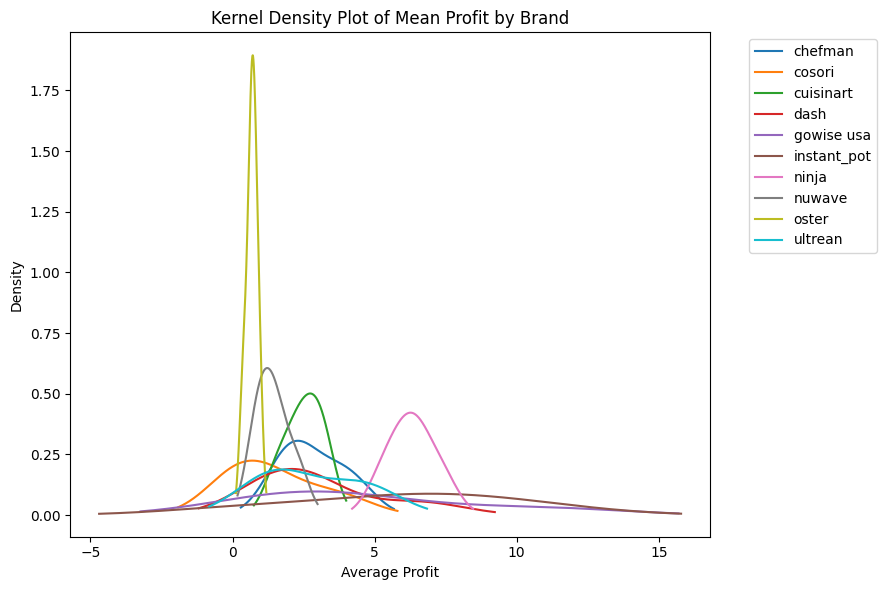

In [17]:
#  mean profit by brand
plt.figure(figsize=(9, 6))

for brand, group in pricing_df.groupby("brand"):
    group["average_profit"].plot(kind="kde", label=brand)

plt.title("Kernel Density Plot of Mean Profit by Brand")
plt.xlabel("Average Profit")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

Unit costs vary widely across brands, while markups are more tightly clustered. Average profit differs more across brands because it depends on both markup and brand share.

### Which brands have the highest share-weighted average profit?

In [18]:
# Find brands with highest share-weighted average profit
profit_by_brand = pricing_df.groupby("brand")[
    "average_profit"
].mean().sort_values(ascending=False)

display(profit_by_brand)

brand
ninja          6.306093
instant_pot    6.010256
gowise usa     4.605764
dash           2.994372
chefman        2.820968
ultrean        2.780864
cuisinart      2.502997
cosori         1.436651
nuwave         1.422858
oster          0.678338
Name: average_profit, dtype: float64

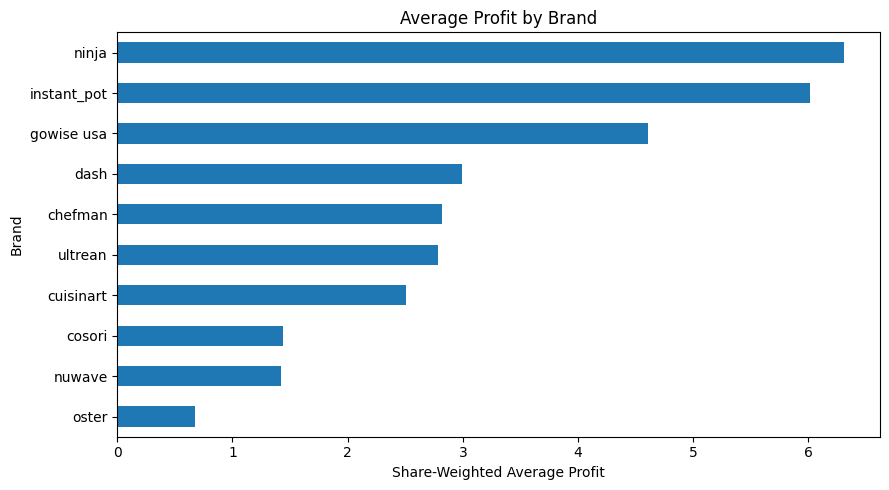

In [19]:
# Plot average profit by brand
plt.figure(figsize=(9, 5))

profit_by_brand.sort_values().plot(kind="barh")

plt.title("Average Profit by Brand")
plt.xlabel("Share-Weighted Average Profit")
plt.ylabel("Brand")

plt.tight_layout()
plt.show()

The brands with the highest share-weighted average profit are **Ninja**, **Instant Pot**, and **GoWise USA**. These brands combine relatively strong markups with higher brand shares, making them the most profitable in this cleaned market.